# Medical Sound Classification — LSTM + Bidirectioneel LSTM

Dit notebook bouwt voort op de bestaande YAMNet pipeline en vervangt de gemiddelde embedding (`np.mean`) door een volledige tijdreeks die door een LSTM wordt verwerkt.

**Wat nieuw is t.o.v. het origineel:**
- `extract_embeddings_sequence()`: geeft de volledige tijdreeks terug (niet gemiddeld)
- Padding/truncatie naar een vaste `max_frames` lengte
- Drie modelvarianten: LSTM, Bidirectioneel LSTM, en 1D CNN (als baseline)
- Metadata combinatie via Functional API
- Vergelijking van de drie modellen

## 0. Imports

In [97]:
import os
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import scipy.signal
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, Model

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print("TensorFlow versie:", tf.__version__)
print("GPU beschikbaar:", tf.config.list_physical_devices('GPU'))

TensorFlow versie: 2.21.0
GPU beschikbaar: []


## 1. Data laden

In [98]:
df_train = pd.read_csv('data/train.csv')
df_test  = pd.read_csv('data/test.csv')

# Verwijder lege file
df_train = df_train.drop(df_train[df_train['candidateID'] == '5ee582f2832c2'].index)

# Missingness flag voor coldPresent
df_train['coldPresent_missing'] = df_train['coldPresent'].isna().astype(int)
df_train['coldPresent'] = df_train['coldPresent'].fillna(0)

print(f"Train samples: {len(df_train)}")
print(df_train['disease'].value_counts())

Train samples: 545
disease
1    238
2    167
0    140
Name: count, dtype: int64


## 2. YAMNet laden

In [99]:
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')
print("YAMNet geladen.")

YAMNet geladen.


## 3. Embedding extractie — tijdreeks (nieuw!)

Het verschil met het origineel: in plaats van `np.mean(embeddings, axis=0)` bewaren we alle tijdsframes.
YAMNet verwerkt audio in vensters van ~0.96s met een hop van ~0.48s.
Bij een segment van 2 seconden krijg je dus ±4 frames, bij een langere opname meer.

In [100]:
def extract_embeddings_sequence(waveform):
    scores, embeddings, spectrogram = yamnet_model(waveform)
    return embeddings.numpy()


def extract_embeddings_mean(waveform):
    return np.mean(embeddings, axis=0)

TODO De extract embeddings mean wordt nooit gebruikt in deze code, wat raar is want het werd speciaal veranderd.

### 3.1 Bepaal een goede max_frames waarde

We samplen een paar bestanden om te zien hoeveel frames we typisch hebben.

In [101]:
# frame_counts = []

# for cid in df_train['candidateID'].head(20):
#     seg_folder = os.path.join("data/sounds/sounds", cid, "cough_segmented")
#     if not os.path.exists(seg_folder):
#         continue
#     for fname in os.listdir(seg_folder):
#         if fname.endswith("_processed.wav"):
#             fp = os.path.join(seg_folder, fname)
#             waveform, sr = librosa.load(fp, sr=16000)
#             waveform = waveform.astype(np.float32)
#             _, emb, _ = yamnet_model(waveform)
#             frame_counts.append(emb.shape[0])

# if frame_counts:
#     print(f"Frames — min: {min(frame_counts)}, max: {max(frame_counts)}, "
#           f"gemiddeld: {np.mean(frame_counts):.1f}, mediaan: {np.median(frame_counts):.0f}")
#     plt.hist(frame_counts, bins=20)
#     plt.xlabel('Aantal YAMNet frames per segment')
#     plt.ylabel('Frequentie')
#     plt.title('Verdeling van frames per audiosegment')
#     plt.axvline(np.percentile(frame_counts, 90), color='r', linestyle='--', label='90e percentiel')
#     plt.legend()
#     plt.show()
    
#     # Stel max_frames in op het 90e percentiel (dekt 90% van de data zonder te veel padding)
#     MAX_FRAMES = int(np.percentile(frame_counts, 90))
#     print(f"\nAanbevolen MAX_FRAMES: {MAX_FRAMES}")
# else:
#     MAX_FRAMES = 30
#     print(f"Geen segmented bestanden gevonden. MAX_FRAMES ingesteld op {MAX_FRAMES}")

In [102]:
# Pas hier aan als je een andere waarde wil testen
MAX_FRAMES = 4  # bijv. 20, 30, 50 ...
print(f"MAX_FRAMES = {MAX_FRAMES}")

MAX_FRAMES = 4


TODO Aangezien deze code redelijk ingewikkeld is kunnen we hier ook gewoon 4 nemen en zeggen dat we er een beetje mee hebben geprutst

## 4. Dataset bouwen

We bouwen twee datasets:
- `X_seq`: tijdreeks embeddings, shape `(samples, MAX_FRAMES, 1024)` → voor LSTM
- `X_meta`: metadata features, shape `(samples, n_meta)` → apart gecombineerd

Cough segmenten + vowel (indien beschikbaar), net als in het origineel.

TODO misschien nog namen veranderen

TODO iedere input is hier een aparte hoest of vowel.

In [103]:
META_COLS = ['age', 'gender', 'tbContactHistory', 'wheezingHistory',
             'phlegmCough', 'familyAsthmaHistory', 'feverHistory',
             'coldPresent', 'packYears', 'coldPresent_missing']

df_filled = df_train.fillna(0)

X_seq  = []  # tijdreeks embeddings     TODO is X_emb een betere naam?
X_meta = []  # metadata
y_list = []  # labels

skipped = 0

for _, row in df_filled.iterrows():
    cid     = row['candidateID']
    disease = row['disease']
    meta    = row[META_COLS].values.astype(np.float32)
    
    # --- Cough segmenten ---
    seg_folder = os.path.join("data/sounds/sounds", cid, "cough_segmented")
    if os.path.exists(seg_folder):
        for fname in os.listdir(seg_folder):
            if fname.endswith("_processed.wav"):
                fp = os.path.join(seg_folder, fname)
                try:
                    waveform, sr = librosa.load(fp, sr=16000)
                    emb_seq = extract_embeddings_sequence(waveform)
                    X_seq.append(emb_seq)
                    X_meta.append(meta)
                    y_list.append(disease)
                except Exception as e:
                    print(f"Fout bij {fp}: {e}")
                    skipped += 1
    
    # # --- Vowel ---
    # vowel_path = os.path.join("data/sounds/sounds", cid, "vowel_processed.wav")
    # if os.path.isfile(vowel_path):
    #     try:
    #         waveform, sr = librosa.load(vowel_path, sr=16000)
    #         emb_seq = extract_embeddings_sequence(waveform)
    #         X_seq.append(emb_seq)
    #         X_meta.append(meta)
    #         y_list.append(disease)
    #     except Exception as e:
    #         print(f"Fout bij {vowel_path}: {e}")
    #         skipped += 1

X_seq  = np.array(X_seq,  dtype=np.float32)   # (samples, MAX_FRAMES, 1024)
X_meta = np.array(X_meta, dtype=np.float32)   # (samples, n_meta)
y_arr  = np.array(y_list)

print(f"X_seq shape : {X_seq.shape}")
print(f"X_meta shape: {X_meta.shape}")
print(f"Labels shape: {y_arr.shape}")
print(f"Overgeslagen : {skipped}")

X_seq shape : (8317, 4, 1024)
X_meta shape: (8317, 10)
Labels shape: (8317,)
Overgeslagen : 0


In [ ]:
# Metadata schalen
scaler = StandardScaler()
X_meta_scaled = scaler.fit_transform(X_meta)

# Labels encoderen
# TODO volgens mij is dit al automatisch gedaan, test een keer zonder dit.
le = LabelEncoder()
y_encoded = le.fit_transform(y_arr)
num_classes = len(le.classes_)
print(f"Klassen: {le.classes_}  ({num_classes} klassen)")

# Train/val split — gestratificeerd
# TODO zeker dit nog een keer bekijken.
splits = train_test_split(
    X_seq,
    X_meta_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

X_seq_train, X_seq_val, X_meta_train, X_meta_val, y_train, y_val = splits

y_train_oh = to_categorical(y_train, num_classes)
y_val_oh   = to_categorical(y_val,   num_classes)

print(f"Training  : {len(X_seq_train)} samples")
print(f"Validatie : {len(X_seq_val)} samples")

Klassen: [0 1 2]  (3 klassen)
Training  : 6653 samples
Validatie : 1664 samples


## 5. Modellen

We bouwen drie varianten en vergelijken ze:

| Model | Beschrijving |
|-------|--------------|
| **LSTM** | Unidirectionele LSTM over tijdreeks + metadata |
| **BiLSTM** | Bidirectionele LSTM (kijkt ook achteruit) + metadata |
| **1D CNN** | Convoluties over de tijdas (sneller, stabiel bij kleine data) + metadata |

TODO dit moet zeker nog een keer getransformeerd worden maar is op zich niet zo moeilijk.

Hier kunnen we wss aparte audio takken maken als we vowels nog willen toevoegen.

In [ ]:
def build_lstm(max_frames, n_meta, num_classes, bidirectional=False):
    """
    Functional API model: tijdreeks (LSTM) + metadata gecombineerd.
    """
    # --- Audio tak ---
    audio_input = layers.Input(shape=(max_frames, 1024), name='audio_seq')
    
    lstm_layer = layers.LSTM(128, return_sequences=True)(audio_input)
    lstm_layer = layers.Dropout(0.3)(lstm_layer)
    lstm_layer = layers.LSTM(64)(lstm_layer)
    lstm_layer = layers.Dropout(0.3)(lstm_layer)
    
    if bidirectional:
        audio_input = layers.Input(shape=(max_frames, 1024), name='audio_seq')
        lstm_layer = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(audio_input)
        lstm_layer = layers.Dropout(0.3)(lstm_layer)
        lstm_layer = layers.Bidirectional(layers.LSTM(64))(lstm_layer)
        lstm_layer = layers.Dropout(0.3)(lstm_layer)
    
    # --- Metadata tak ---
    meta_input = layers.Input(shape=(n_meta,), name='metadata')
    meta_dense = layers.Dense(32, activation='relu')(meta_input)
    meta_dense = layers.Dropout(0.2)(meta_dense)
    
    # --- Combineer ---
    combined = layers.concatenate([lstm_layer, meta_dense])
    out = layers.Dense(64, activation='relu')(combined)
    out = layers.Dropout(0.3)(out)
    out = layers.Dense(num_classes, activation='softmax')(out)
    
    model = Model(inputs=[audio_input, meta_input], outputs=out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), #TODO
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_1d_cnn(max_frames, n_meta, num_classes):
    """
    1D CNN over de tijdreeks van embeddings — vaak stabieler bij kleine datasets.
    """
    # --- Audio tak ---
    audio_input = layers.Input(shape=(max_frames, 1024), name='audio_seq')
    
    x = layers.Conv1D(128, kernel_size=3, activation='relu', padding='same')(audio_input)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Conv1D(64, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.4)(x)
    
    # --- Metadata tak ---
    meta_input = layers.Input(shape=(n_meta,), name='metadata')
    meta_dense = layers.Dense(32, activation='relu')(meta_input)
    meta_dense = layers.Dropout(0.2)(meta_dense)
    
    # --- Combineer ---
    combined = layers.concatenate([x, meta_dense])
    out = layers.Dense(64, activation='relu')(combined)
    out = layers.Dropout(0.3)(out)
    out = layers.Dense(num_classes, activation='softmax')(out)
    
    model = Model(inputs=[audio_input, meta_input], outputs=out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


n_meta = X_meta_scaled.shape[1]
print(f"n_meta features: {n_meta}")

n_meta features: 10


## 6. Training

We trainen de drie modellen na elkaar en slaan de resultaten op voor vergelijking.

In [106]:
def train_model(model, name, epochs=60, batch_size=16):
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print(f"{'='*50}")
    model.summary()
    
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
    
    history = model.fit(
        [X_seq_train, X_meta_train], y_train_oh,
        validation_data=([X_seq_val, X_meta_val], y_val_oh),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=1
    )
    
    val_loss, val_acc = model.evaluate([X_seq_val, X_meta_val], y_val_oh, verbose=0)
    y_pred = np.argmax(model.predict([X_seq_val, X_meta_val], verbose=0), axis=1)
    macro_f1 = f1_score(y_val, y_pred, average='macro')
    
    print(f"\n{name} — Val Accuracy: {val_acc:.4f} | Macro F1: {macro_f1:.4f}")
    print(classification_report(y_val, y_pred, target_names=le.classes_.astype(str)))
    
    return history, val_acc, macro_f1, y_pred

In [107]:
# --- LSTM ---
lstm_model = build_lstm(MAX_FRAMES, n_meta, num_classes, bidirectional=False)
hist_lstm, acc_lstm, f1_lstm, pred_lstm = train_model(lstm_model, "LSTM")


Training: LSTM


Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ audio_seq           │ (None, 4, 1024)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_30 (LSTM)      │ (None, 4, 128)    │    590,336 │ audio_seq[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_65          │ (None, 4, 128)    │          0 │ lstm_30[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata            │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_31 (LSTM)      │ (None, 64)        │     49,408 │ dropout_65[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_45 (Dense)    │ (None, 32)        │        352 │ metadata[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_66          │ (None, 64)        │          0 │ lstm_31[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_67          │ (None, 32)        │          0 │ dense_45[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_15      │ (None, 96)        │          0 │ dropout_66[0][0], │
│ (Concatenate)       │                   │            │ dropout_67[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_46 (Dense)    │ (None, 64)        │      6,208 │ concatenate_15[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_68          │ (None, 64)        │          0 │ dense_46[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_47 (Dense)    │ (None, 3)         │        195 │ dropout_68[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 646,499 (2.47 MB)

 Trainable params: 646,499 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7300 - loss: 0.6405 - val_accuracy: 0.8281 - val_loss: 0.4582
Epoch 2/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8223 - loss: 0.4678 - val_accuracy: 0.8323 - val_loss: 0.4231
Epoch 3/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8342 - loss: 0.4382 - val_accuracy: 0.8407 - val_loss: 0.3929
Epoch 4/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8384 - loss: 0.4166 - val_accuracy: 0.8395 - val_loss: 0.3839
Epoch 5/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8470 - loss: 0.4019 - val_accuracy: 0.8498 - val_loss: 0.3629
Epoch 6/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8533 - loss: 0.3792 - val_accuracy: 0.8504 - val_loss: 0.3578
Epoch 7/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8589 - loss: 0.3689 - val_accuracy: 0.8558 - val_loss: 0.3423
Epoch 8/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8611 - loss: 0.3607 - val_accuracy: 0.

In [108]:
# --- Bidirectioneel LSTM ---
bilstm_model = build_lstm(MAX_FRAMES, n_meta, num_classes, bidirectional=True)
hist_bilstm, acc_bilstm, f1_bilstm, pred_bilstm = train_model(bilstm_model, "BiLSTM")


Training: BiLSTM


Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ audio_seq           │ (None, 4, 1024)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_10    │ (None, 4, 256)    │  1,180,672 │ audio_seq[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_71          │ (None, 4, 256)    │          0 │ bidirectional_10… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata            │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_11    │ (None, 128)       │    164,352 │ dropout_71[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_48 (Dense)    │ (None, 32)        │        352 │ metadata[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_72          │ (None, 128)       │          0 │ bidirectional_11… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_73          │ (None, 32)        │          0 │ dense_48[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_16      │ (None, 160)       │          0 │ dropout_72[0][0], │
│ (Concatenate)       │                   │            │ dropout_73[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_49 (Dense)    │ (None, 64)        │     10,304 │ concatenate_16[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_74          │ (None, 64)        │          0 │ dense_49[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_50 (Dense)    │ (None, 3)         │        195 │ dropout_74[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,355,875 (5.17 MB)

 Trainable params: 1,355,875 (5.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.7445 - loss: 0.6238 - val_accuracy: 0.8113 - val_loss: 0.4779
Epoch 2/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8205 - loss: 0.4768 - val_accuracy: 0.8347 - val_loss: 0.4268
Epoch 3/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8255 - loss: 0.4442 - val_accuracy: 0.8365 - val_loss: 0.4047
Epoch 4/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8426 - loss: 0.4180 - val_accuracy: 0.8395 - val_loss: 0.3888
Epoch 5/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8452 - loss: 0.4044 - val_accuracy: 0.8486 - val_loss: 0.3710
Epoch 6/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8495 - loss: 0.3857 - val_accuracy: 0.8510 - val_loss: 0.3595
Epoch 7/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8542 - loss: 0.3707 - val_accuracy: 0.8540 - val_loss: 0.3557
Epoch 8/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8629 - loss: 0.3471 - val_accu

In [109]:
# --- 1D CNN ---
cnn_model = build_1d_cnn(MAX_FRAMES, n_meta, num_classes)
hist_cnn, acc_cnn, f1_cnn, pred_cnn = train_model(cnn_model, "1D CNN")


Training: 1D CNN


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ audio_seq           │ (None, 4, 1024)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 4, 128)    │    393,344 │ audio_seq[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 4, 128)    │        512 │ conv1d_10[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_5     │ (None, 2, 128)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 2, 64)     │     24,640 │ max_pooling1d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2, 64)     │        256 │ conv1d_11[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata            │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_51 (Dense)    │ (None, 32)        │        352 │ metadata[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_75          │ (None, 64)        │          0 │ global_average_p… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_76          │ (None, 32)        │          0 │ dense_51[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_17      │ (None, 96)        │          0 │ dropout_75[0][0], │
│ (Concatenate)       │                   │            │ dropout_76[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_52 (Dense)    │ (None, 64)        │      6,208 │ concatenate_17[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_77          │ (None, 64)        │          0 │ dense_52[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_53 (Dense)    │ (None, 3)         │        195 │ dropout_77[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 425,507 (1.62 MB)

 Trainable params: 425,123 (1.62 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7296 - loss: 0.6489 - val_accuracy: 0.8041 - val_loss: 0.4819
Epoch 2/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8073 - loss: 0.4996 - val_accuracy: 0.8317 - val_loss: 0.4431
Epoch 3/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8217 - loss: 0.4616 - val_accuracy: 0.8329 - val_loss: 0.4139
Epoch 4/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8362 - loss: 0.4278 - val_accuracy: 0.8317 - val_loss: 0.3951
Epoch 5/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8371 - loss: 0.4140 - val_accuracy: 0.8389 - val_loss: 0.3850
Epoch 6/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8438 - loss: 0.3968 - val_accuracy: 0.8504 - val_loss: 0.3630
Epoch 7/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8447 - loss: 0.3920 - val_accuracy: 0.8480 - val_loss: 0.3552
Epoch 8/60
416/416 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8545 - loss: 0.3739 - val_accuracy: 0.

## 7. Vergelijking

 Model  Val Accuracy  Macro F1
  LSTM      0.873197  0.868785
BiLSTM      0.874399  0.870260
1D CNN      0.890625  0.886047


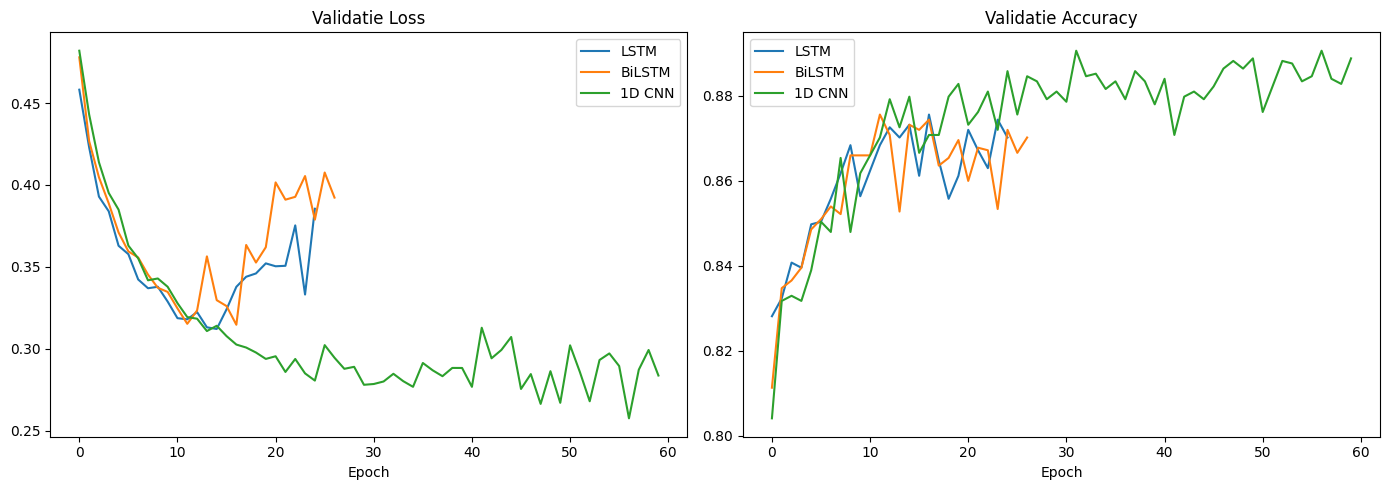

In [110]:
results = pd.DataFrame({
    'Model'      : ['LSTM', 'BiLSTM', '1D CNN'],
    'Val Accuracy': [acc_lstm, acc_bilstm, acc_cnn],
    'Macro F1'   : [f1_lstm,  f1_bilstm,  f1_cnn]
})
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for hist, name in [(hist_lstm, 'LSTM'), (hist_bilstm, 'BiLSTM'), (hist_cnn, '1D CNN')]:
    axes[0].plot(hist.history['val_loss'], label=name)
    axes[1].plot(hist.history['val_accuracy'], label=name)

axes[0].set_title('Validatie Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].set_title('Validatie Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

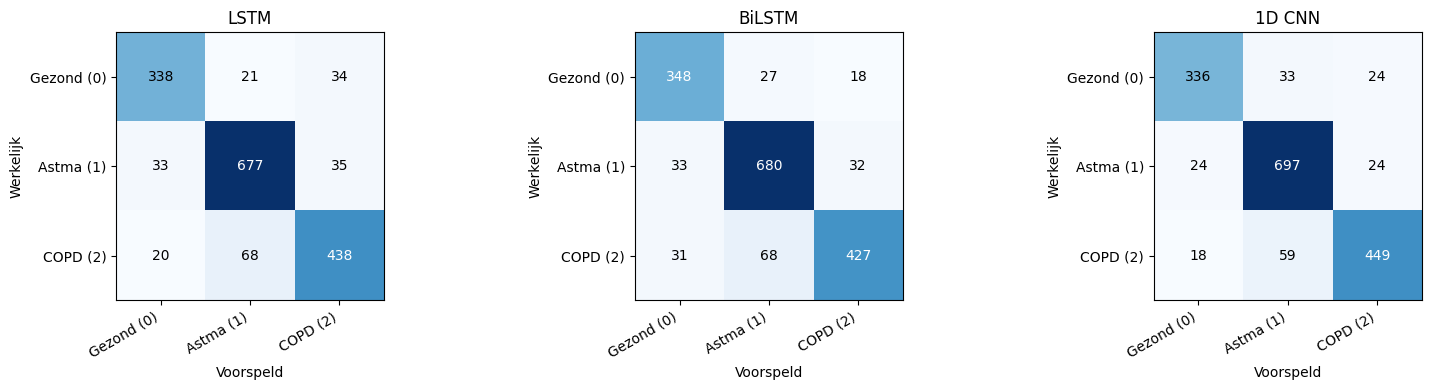

In [111]:
# Confusion matrices naast elkaar
class_names = ['Gezond (0)', 'Astma (1)', 'COPD (2)']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, preds, name in [
    (axes[0], pred_lstm,   'LSTM'),
    (axes[1], pred_bilstm, 'BiLSTM'),
    (axes[2], pred_cnn,    '1D CNN')
]:
    cm = confusion_matrix(y_val, preds)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(name)
    ax.set_xticks(range(num_classes))
    ax.set_yticks(range(num_classes))
    ax.set_xticklabels(class_names, rotation=30, ha='right')
    ax.set_yticklabels(class_names)
    ax.set_xlabel('Voorspeld')
    ax.set_ylabel('Werkelijk')
    for i in range(num_classes):
        for j in range(num_classes):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()

## 8. Beste model opslaan

In [112]:
# import joblib

best_f1 = max(f1_lstm, f1_bilstm, f1_cnn)
best_name = ['LSTM', 'BiLSTM', '1D CNN'][[f1_lstm, f1_bilstm, f1_cnn].index(best_f1)]
best_model = {'LSTM': lstm_model, 'BiLSTM': bilstm_model, '1D CNN': cnn_model}[best_name]

print(f"Beste model: {best_name} (Macro F1 = {best_f1:.4f})")

# best_model.save(f"best_model_{best_name.replace(' ', '_').lower()}.keras")
# joblib.dump(scaler, "scaler_lstm_experiment.pkl")
# joblib.dump(le,     "label_encoder_lstm_experiment.pkl")

# print("Model, scaler en label encoder opgeslagen.")

Beste model: 1D CNN (Macro F1 = 0.8860)


## 9. Inferentie op testset (optioneel)

Pas dit aan naar de structuur van jouw test CSV.

In [113]:
# Uncomment en pas aan zodra je de testset wil evalueren

# df_test_filled = df_test.fillna(0)
# if 'coldPresent_missing' not in df_test_filled.columns:
#     df_test_filled['coldPresent_missing'] = df_test['coldPresent'].isna().astype(int)

# X_seq_test  = []
# X_meta_test = []
# test_ids    = []

# for _, row in df_test_filled.iterrows():
#     cid  = row['candidateID']
#     meta = row[META_COLS].values.astype(np.float32)
#
#     seg_folder = os.path.join("data/sounds/sounds", cid, "cough_segmented")
#     if os.path.exists(seg_folder):
#         for fname in os.listdir(seg_folder):
#             if fname.endswith("_processed.wav"):
#                 fp = os.path.join(seg_folder, fname)
#                 waveform, _ = librosa.load(fp, sr=16000)
#                 emb_seq = extract_embeddings_sequence(waveform, MAX_FRAMES)
#                 X_seq_test.append(emb_seq)
#                 X_meta_test.append(meta)
#                 test_ids.append(cid)

# X_seq_test  = np.array(X_seq_test,  dtype=np.float32)
# X_meta_test = scaler.transform(np.array(X_meta_test, dtype=np.float32))

# y_pred_test = np.argmax(best_model.predict([X_seq_test, X_meta_test]), axis=1)
# y_pred_labels = le.inverse_transform(y_pred_test)

# submission = pd.DataFrame({'candidateID': test_ids, 'disease': y_pred_labels})
# # Aggregeer per kandidaat (meerdere segmenten → majority vote)
# submission = submission.groupby('candidateID')['disease'].agg(lambda x: x.mode()[0]).reset_index()
# submission.to_csv('submission_lstm.csv', index=False)
# print(submission.head())

print("Testset inferentie klaar om te gebruiken — uncomment de code hierboven.")

Testset inferentie klaar om te gebruiken — uncomment de code hierboven.
